In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm

In [2]:
cd ../../

/Users/ann/Documents/Quant finance study/WSQ/quant_project


In [3]:
from src.get_data.read_data import get_rets
from src.ols.ols import compute_resid

from src.get_data.read_data import get_rets
from src.signal_construction.transform_signal import transform_signal, dollar_neutral_weights

from src.signal_construction.reduce_trading import partial_adjustment_weights

import src.analysis.stats as stats

In [4]:
start_ts = '2022-01-01'
end_ts = '2025-12-31'

In [5]:
parquet_path = f"src/data/rets_full_{start_ts[:4]}_to_{end_ts[:4]}.parquet"

In [6]:
if os.path.exists(parquet_path):
    rets = pd.read_parquet(parquet_path)
else:
    rets, px = get_rets(freq='4h',start_ts = start_ts,end_ts=end_ts)
    rets.to_parquet(parquet_path)

In [7]:
strat_time = 4

In [8]:
daily_rets = rets.iloc[115:,]   #rets.iloc[5::6,]
daily_rets = daily_rets.loc[:"20241231"]
#daily_rets = daily_rets.dropna(axis=1)

In [9]:
print("Daily rets shape:", daily_rets.shape)

Daily rets shape: (6461, 72)


In [10]:
daily_rets.shape

(6461, 72)

In [11]:
def kill_flat_tails(ret, window=50, tol=1e-8):
    rolling_var = ret.rolling(window).var()
    dead_mask = rolling_var < tol
    
    ret_clean = ret.copy()
    
    for col in ret.columns:
        dead_idx = dead_mask[col]
        if dead_idx.any():
            first_dead = dead_idx.idxmax()  # first True
            if dead_idx.loc[first_dead]:
                ret_clean.loc[first_dead:, col] = np.nan
    
    return ret_clean

In [12]:
#daily_rets = kill_flat_tails(daily_rets)

In [13]:
daily_rets.index.min(), daily_rets.index.max()

(Timestamp('2022-01-20 04:00:00+0000', tz='UTC'),
 Timestamp('2024-12-31 20:00:00+0000', tz='UTC'))

In [14]:
daily_rets.shape

(6461, 72)

In [15]:
# shuffled = daily_rets.copy()

# for col in shuffled.columns:
#     shuffled[col] = np.random.permutation(shuffled[col].values)

# daily_rets = shuffled   

In [16]:
mkt_list = ["BTCUSDT", "ETHUSDT"]

net_sharpes = {x: {} for x in mkt_list}
gross_sharpes = {x: {} for x in mkt_list}
gross_cum_dict = {x: {} for x in mkt_list}
net_cum_dict = {x: {} for x in mkt_list}

betas = {x: {} for x in mkt_list}
alphas = {x: {} for x in mkt_list}

alpha_tstats = {x: {} for x in mkt_list}
avg_ann = {x: {} for x in mkt_list}
vol_ann = {x: {} for x in mkt_list}
hit_rate = {x: {} for x in mkt_list}
r_squared = {x: {} for x in mkt_list}

window_sizes = [x * 10 * 24 // strat_time for x in range(1, 12)]


for mkt_ticker in mkt_list:

    for window_size in tqdm(window_sizes):

        resid_df = compute_resid(daily_rets, window_size=window_size, mkt_ticker=mkt_ticker)
        resid_df.drop(columns=[mkt_ticker], inplace=True)

        resid_rank_thresh = transform_signal(-resid_df, how="rank", rank_thresh=0.1)
        w = dollar_neutral_weights(resid_rank_thresh)
        w = partial_adjustment_weights(w, rho=0.7)

        combo = (w.shift() * daily_rets).sum(axis=1)

        to = (w.fillna(0) - w.shift().fillna(0)).abs().sum(1)
        gross_ret = (w.shift()*daily_rets).sum(1)
        tcost_bps = 20 # (comissions + slip)
        net_ret = gross_ret.subtract(to*tcost_bps*1e-4,fill_value=0)

        # Cumulative returns
        gross_cum_dict[mkt_ticker][window_size/(24//strat_time)] = (1 + gross_ret).cumprod() - 1
        net_cum_dict[mkt_ticker][window_size/(24//strat_time)] = (1 + net_ret).cumprod() - 1

        net_sharpes[mkt_ticker][window_size/(24//strat_time)] = net_ret.mean() / net_ret.std() * np.sqrt(252*(24/strat_time))
        gross_sharpes[mkt_ticker][window_size/(24//strat_time)] = gross_ret.mean() / gross_ret.std() * np.sqrt(252*(24/strat_time))

        full_stats = stats.compute_full_stats(gross_ret, daily_rets[mkt_ticker])
        betas[mkt_ticker][window_size/(24//strat_time)] = full_stats["beta"].iloc[0]
        alphas[mkt_ticker][window_size/(24//strat_time)] = full_stats["alpha_ann"].iloc[0]
        alpha_tstats[mkt_ticker][window_size/(24//strat_time)] = full_stats["alpha_tstat"].iloc[0]
        avg_ann[mkt_ticker][window_size/(24//strat_time)] = full_stats["avg_ann"].iloc[0]
        vol_ann[mkt_ticker][window_size/(24//strat_time)] = full_stats["vol_ann"].iloc[0]
        hit_rate[mkt_ticker][window_size/(24//strat_time)] = full_stats["hit_rate"].iloc[0]
        r_squared[mkt_ticker][window_size/(24//strat_time)] = full_stats["r_squared"].iloc[0]



  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [17:23<00:00, 94.87s/it]


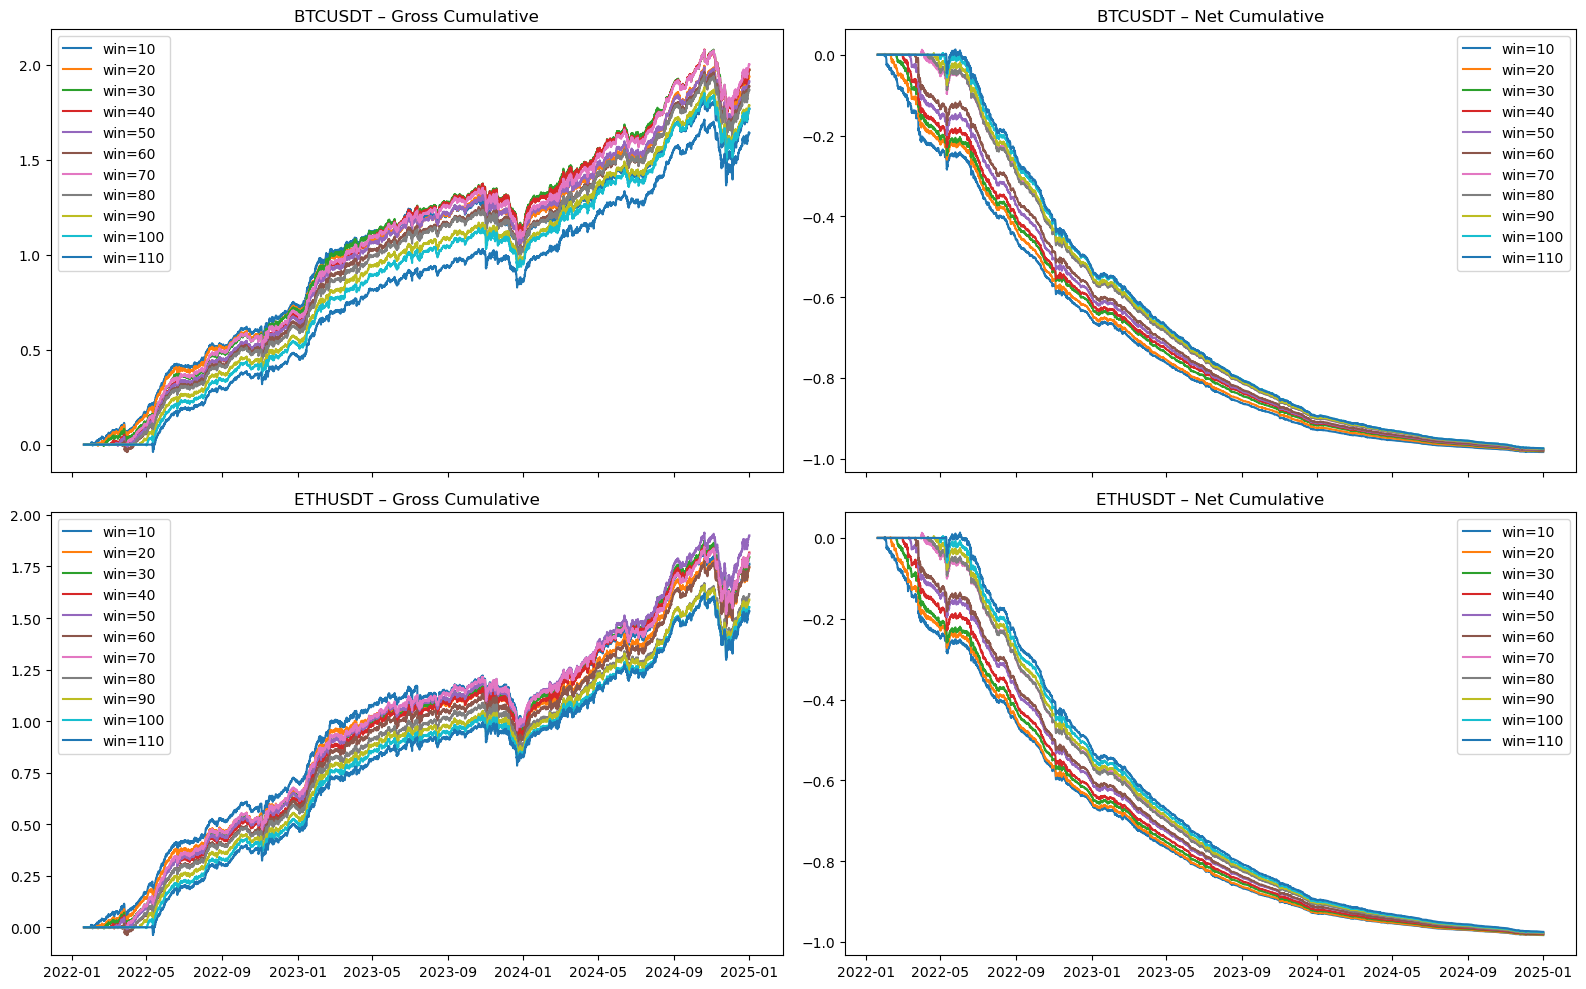

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for row, mkt_ticker in enumerate(mkt_list):

    for window_size in (window_sizes):

        label = f"win={int(window_size/(24//strat_time))}"

        axes[row, 0].plot(gross_cum_dict[mkt_ticker][window_size/(24//strat_time)], label=label)

        axes[row, 1].plot(net_cum_dict[mkt_ticker][window_size/(24//strat_time)], label=label)
    
    axes[row, 0].set_title(f"{mkt_ticker} – Gross Cumulative")
    axes[row, 1].set_title(f"{mkt_ticker} – Net Cumulative")
    axes[row, 0].legend()
    axes[row, 1].legend()
plt.tight_layout()
plt.show()

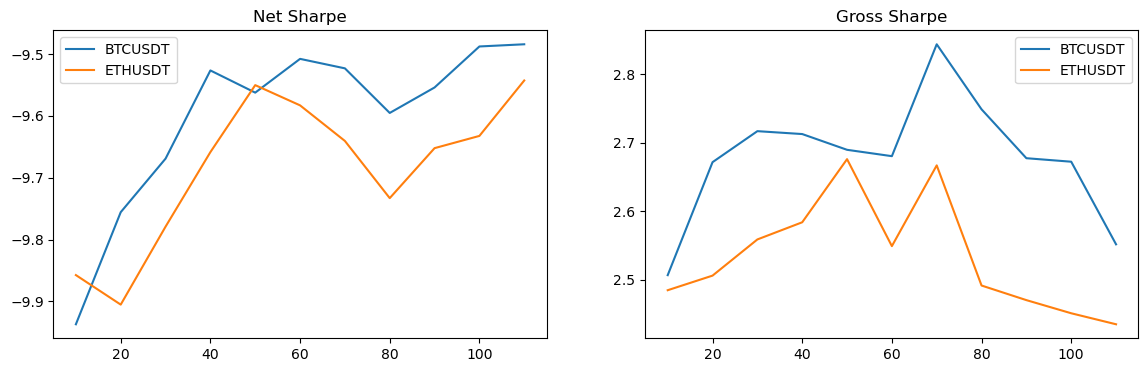

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

pd.DataFrame(net_sharpes).plot(ax=ax[0])
pd.DataFrame(gross_sharpes).plot(ax=ax[1])

ax[0].set_title("Net Sharpe")
ax[1].set_title("Gross Sharpe")

plt.show()

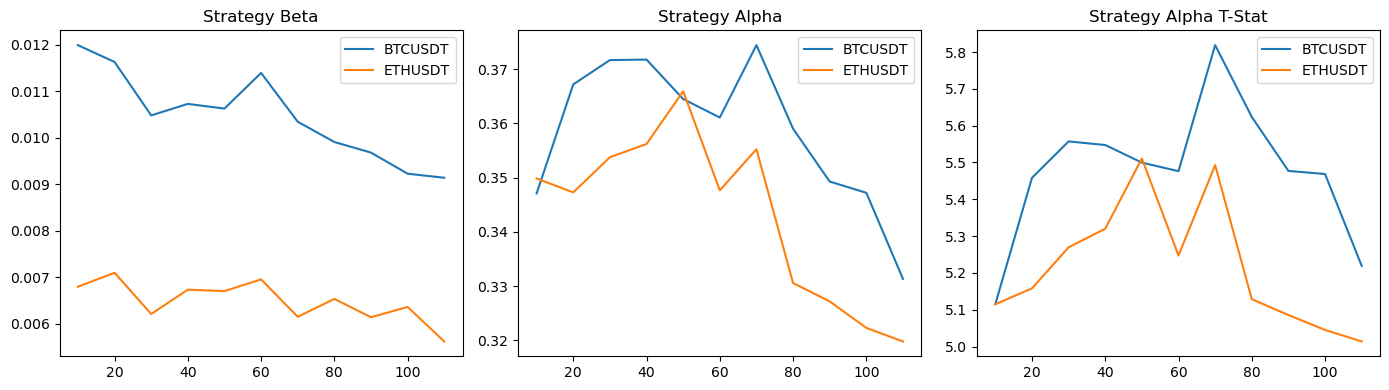

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

pd.DataFrame(betas).plot(ax=ax[0])
ax[0].set_title("Strategy Beta")

pd.DataFrame(alphas).plot(ax=ax[1])
ax[1].set_title("Strategy Alpha")

pd.DataFrame(alpha_tstats).plot(ax=ax[2])
ax[2].set_title("Strategy Alpha T-Stat")

plt.tight_layout()
plt.show()


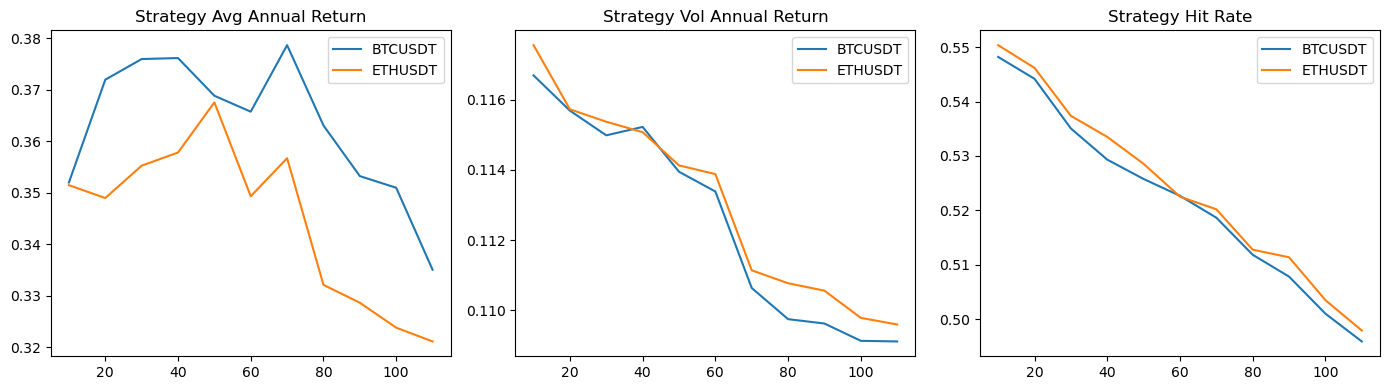

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

pd.DataFrame(avg_ann).plot(ax=ax[0])
ax[0].set_title("Strategy Avg Annual Return")

pd.DataFrame(vol_ann).plot(ax=ax[1])
ax[1].set_title("Strategy Vol Annual Return")

pd.DataFrame(hit_rate).plot(ax=ax[2])
ax[2].set_title("Strategy Hit Rate")


plt.tight_layout()
plt.show()

In [21]:
gross_ret.mean(), gross_ret.std()

(0.00014663567481231035, 0.002341960378095525)